# Phase 6 – Modell v2 Training

**Ziel:** Random Forest v2 (19 Features) trainieren, mit v1 (7 Features) vergleichen,
Feature Importance plotten und als `models/ems_forecast_rf_v2.pkl` speichern.

**Voraussetzung:** Phase 5 (`05_feature_engineering_v2.ipynb`) muss abgeschlossen sein.

In [1]:
import sys
import warnings
from pathlib import Path
from math import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import FEATURE_COLUMNS, FEATURES_V2, GEBIET_NAMES

print('Imports OK')

Imports OK


## 6.1 – Daten laden

In [2]:
TARGET = 'einsatz_count'

# v2-Feature-Set
df_v2 = joblib.load(ROOT / 'models' / 'features_v2.pkl')
X2 = df_v2[FEATURES_V2]
y2 = df_v2[TARGET]

# v1-Feature-Set (gleiche Zeilenanzahl/-reihenfolge wie v2 -> identischer Split moeglich)
df_v1 = joblib.load(ROOT / 'models' / 'features_aggregated.pkl')
X1 = df_v1[FEATURE_COLUMNS]
y1 = df_v1[TARGET]

print(f'v1 Shape: {X1.shape}  |  v2 Shape: {X2.shape}')
assert len(X1) == len(X2), 'v1 und v2 muessen dieselbe Zeilenanzahl haben fuer einen fairen Vergleich'

# Identischer Split (test_size=0.2, random_state=42) fuer v1 und v2
X2_train, X2_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
assert y1_test.index.equals(y_test.index), 'Splits muessen fuer v1 und v2 uebereinstimmen'

print(f'Train: {X2_train.shape}  |  Test: {X2_test.shape}')

v1 Shape: (33437, 7)  |  v2 Shape: (33437, 19)
Train: (26749, 19)  |  Test: (6688, 19)


## 6.2 – Random Forest v2 trainieren

In [3]:
# Hyperparameter exakt wie in AGENT.md vorgegeben (identisch zu v1)
rf_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_v2.fit(X2_train, y_train)
print('Training abgeschlossen.')
print(f'Anzahl Baeume: {rf_v2.n_estimators}  |  Features: {rf_v2.n_features_in_}')

Training abgeschlossen.
Anzahl Baeume: 200  |  Features: 19


## 6.3 – Metriken berechnen & mit v1 vergleichen

In [4]:
# v1-Modell laden und auf dem identischen Test-Split auswerten (fairer Vergleich)
rf_v1 = joblib.load(ROOT / 'models' / 'ems_forecast_rf_v1.pkl')
y_pred_v1 = rf_v1.predict(X1_test)
mae_v1  = mean_absolute_error(y1_test, y_pred_v1)
rmse_v1 = sqrt(mean_squared_error(y1_test, y_pred_v1))
r2_v1   = r2_score(y1_test, y_pred_v1)

y_pred_v2 = rf_v2.predict(X2_test)
mae_v2  = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = sqrt(mean_squared_error(y_test, y_pred_v2))
r2_v2   = r2_score(y_test, y_pred_v2)

header = f'{"Modell":<14} {"Features":>8} {"MAE":>8} {"RMSE":>8} {"R2":>8}'
sep    = '-' * len(header)
print(sep)
print(header)
print(sep)
print(f'{"v1 (Basis)":<14} {len(FEATURE_COLUMNS):>8} {mae_v1:>8.4f} {rmse_v1:>8.4f} {r2_v1:>8.4f}')
print(f'{"v2 (Voll)":<14} {len(FEATURES_V2):>8} {mae_v2:>8.4f} {rmse_v2:>8.4f} {r2_v2:>8.4f}')
print(sep)

if mae_v2 <= mae_v1:
    print(f'\nv2 besser oder gleich gut wie v1 (MAE {mae_v2:.4f} <= {mae_v1:.4f})')
else:
    print(f'\nv2 schlechter als v1 (MAE {mae_v2:.4f} > {mae_v1:.4f})')

--------------------------------------------------
Modell         Features      MAE     RMSE       R2
--------------------------------------------------
v1 (Basis)            7   0.2462   0.4088  -0.1377
v2 (Voll)            19   0.2511   0.3930  -0.0518
--------------------------------------------------

v2 schlechter als v1 (MAE 0.2511 > 0.2462)


## 6.4 – Feature Importance v2

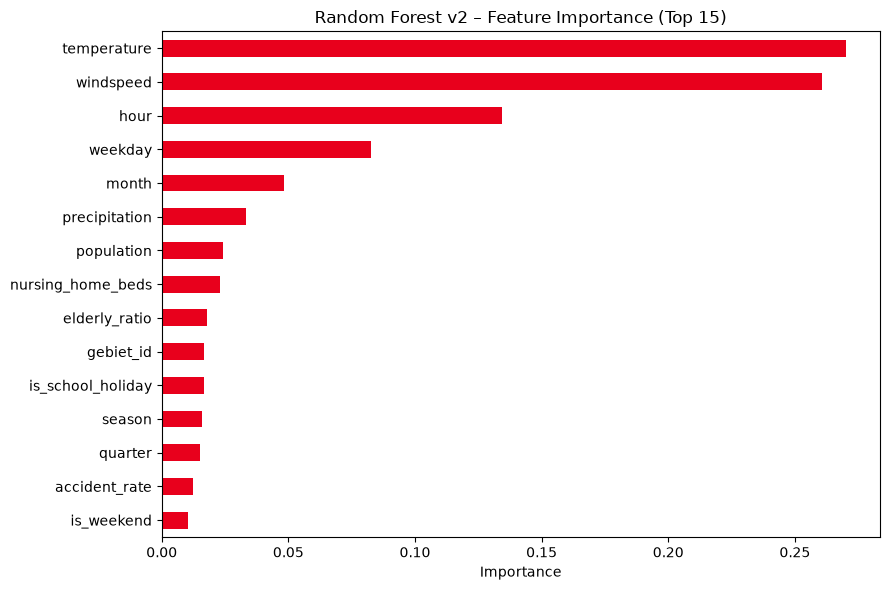

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\feature_importance_v2.png

Top 5 wichtigste Features:
temperature    0.270101
windspeed      0.260773
hour           0.134479
weekday        0.082564
month          0.048184
dtype: float64

Rang der neuen (nicht in v1 enthaltenen) Features:
  is_holiday: Rang 17 von 19 (importance=0.0057)
  is_school_holiday: Rang 11 von 19 (importance=0.0167)
  population: Rang 7 von 19 (importance=0.0240)
  elderly_ratio: Rang 9 von 19 (importance=0.0177)
  nursing_home_beds: Rang 8 von 19 (importance=0.0230)
  has_major_event: Rang 16 von 19 (importance=0.0082)
  accident_rate: Rang 14 von 19 (importance=0.0125)
  temperature: Rang 1 von 19 (importance=0.2701)
  precipitation: Rang 6 von 19 (importance=0.0334)
  snowfall: Rang 18 von 19 (importance=0.0033)
  windspeed: Rang 2 von 19 (importance=0.2608)
  is_extreme_weather: Rang 19 von 19 (importance=0.0010)


In [5]:
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

importances = pd.Series(rf_v2.feature_importances_, index=FEATURES_V2).sort_values(ascending=False)
top15 = importances.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot.barh(ax=ax, color='#E8001C')
ax.set_title('Random Forest v2 – Feature Importance (Top 15)')
ax.set_xlabel('Importance')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'feature_importance_v2.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

print('\nTop 5 wichtigste Features:')
print(importances.head(5))

neue_features = [c for c in FEATURES_V2 if c not in FEATURE_COLUMNS]
print(f'\nRang der neuen (nicht in v1 enthaltenen) Features:')
rang = importances.rank(ascending=False).astype(int)
for f in neue_features:
    print(f'  {f}: Rang {rang[f]} von {len(FEATURES_V2)} (importance={importances[f]:.4f})')

## 6.5 – Modell speichern

In [6]:
model_path = ROOT / 'models' / 'ems_forecast_rf_v2.pkl'
joblib.dump(rf_v2, model_path)

size_kb = model_path.stat().st_size / 1024
print(f'Modell gespeichert: {model_path}')
print(f'Dateigroesse: {size_kb:.1f} KB')

Modell gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\models\ems_forecast_rf_v2.pkl
Dateigroesse: 71866.8 KB


---
## Phase 6 abgeschlossen
- Random Forest v2 trainiert und mit v1 verglichen (identischer Test-Split)
- `models/ems_forecast_rf_v2.pkl` gespeichert
- Feature-Importance-Plot unter `output/feature_importance_v2.png`

**Hinweis:** Schritt 6.6 aus AGENT.md (FastAPI-Service `main.py` auf v2 umstellen) wurde
bewusst **nicht** durchgeführt – das war nicht Teil des Auftrags und betrifft den
laufenden Service, nicht die Notebooks/Modelle.